# 🛒 Predicting Consumer Shopping Channel Preference
## Model Selection & Initial Evaluation
---
**Prerequisite:** Run `data_preprocessing.ipynb` first to generate `../models/*.csv` and `*.pkl` files.

**Models evaluated:**
- 🧑 **Human-selected:** Logistic Regression (interpretable, strong baseline)
- 🤖 **AI-recommended:** XGBoost (handles imbalance, non-linear patterns)
- 🌲 **Additional:** Random Forest, SVM, Gradient Boosting, LightGBM

In [2]:
# ── Install (run once) ───────────────────────────────────────────────────────
!py -m pip install scikit-learn xgboost lightgbm matplotlib seaborn joblib -q

# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import json, os, warnings
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

# Scikit-learn classifiers
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print('✅ Libraries ready!')

✅ Libraries ready!


## 1️⃣ Load Preprocessed Data

In [3]:
# ─── Load train/test sets created in data_preprocessing.ipynb ────────────────
X_train = pd.read_csv('../models/X_train.csv')
X_test  = pd.read_csv('../models/X_test.csv')
y_train = pd.read_csv('../models/y_train.csv').squeeze()  # Convert DataFrame → Series
y_test  = pd.read_csv('../models/y_test.csv').squeeze()

# Load label encoder to get class names
le_target     = joblib.load('../models/label_encoder_target.pkl')
CLASS_NAMES   = le_target.classes_.tolist()  # ['Hybrid', 'Online', 'Store']

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  | y_test : {y_test.shape}')
print(f'Classes: {CLASS_NAMES}')

X_train: (24585, 29) | y_train: (24585,)
X_test : (2358, 29)  | y_test : (2358,)
Classes: ['Hybrid', 'Online', 'Store']


## 2️⃣ Evaluation Helper Function

In [5]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, class_names):
    """
    Train a model and compute comprehensive evaluation metrics.
    Returns a results dictionary.
    """
    # ── Train ────────────────────────────────────────────────────────────────
    model.fit(X_tr, y_tr)

    # ── Predict ──────────────────────────────────────────────────────────────
    y_pred = model.predict(X_te)

    # ── Metrics ──────────────────────────────────────────────────────────────
    acc  = accuracy_score(y_te, y_pred)
    f1_w = f1_score(y_te, y_pred, average='weighted')
    f1_m = f1_score(y_te, y_pred, average='macro')
    prec = precision_score(y_te, y_pred, average='weighted')
    rec  = recall_score(y_te, y_pred, average='weighted')

    # ── Cross-validation (5-fold stratified) ─────────────────────────────────
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy', n_jobs=-1)

    print('\n' + '='*60)
    print(f'  MODEL: {name}')
    print('='*60)
    print(f'  Accuracy         : {acc:.4f}')
    print(f'  Weighted F1-Score: {f1_w:.4f}')
    print(f'  Macro F1-Score   : {f1_m:.4f}')
    print(f'  Precision (W)    : {prec:.4f}')
    print(f'  Recall (W)       : {rec:.4f}')
    print(f'  CV Accuracy      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_te, y_pred, target_names=class_names))

    return {
        'Model'        : name,
        'Accuracy'     : round(acc, 4),
        'Weighted F1'  : round(f1_w, 4),
        'Macro F1'     : round(f1_m, 4),
        'Precision (W)': round(prec, 4),
        'Recall (W)'   : round(rec, 4),
        'CV Mean'      : round(cv_scores.mean(), 4),
        'CV Std'       : round(cv_scores.std(), 4),
        'trained_model': model,
        'y_pred'       : y_pred
    }

print('✅ Helper function defined!')

✅ Helper function defined!


## 3️⃣ Human-Selected Model: Logistic Regression

**Rationale:** Logistic Regression was chosen because:
- It is highly interpretable — coefficients directly show feature influence
- It is computationally efficient on tabular data
- It provides probability estimates for each class
- It serves as a reliable baseline to compare against more complex models
- With proper regularization (`C` parameter), it handles multicollinearity well

In [6]:
# ─── Logistic Regression (Human-Selected Model) ───────────────────────────────
lr_model = LogisticRegression(
    max_iter=1000,          # Enough iterations to converge
    C=1.0,                  # Regularization strength (inverse)
    solver='lbfgs',         # Efficient for multiclass problems
    multi_class='auto',     # Handles 3 classes automatically
    random_state=42
)

lr_results = evaluate_model(
    'Logistic Regression (Human)', lr_model,
    X_train, y_train, X_test, y_test, CLASS_NAMES
)


  MODEL: Logistic Regression (Human)
  Accuracy         : 0.9695
  Weighted F1-Score: 0.9742
  Macro F1-Score   : 0.8752
  Precision (W)    : 0.9845
  Recall (W)       : 0.9695
  CV Accuracy      : 0.9787 ± 0.0015

Classification Report:
              precision    recall  f1-score   support

      Hybrid       0.51      1.00      0.67        74
      Online       1.00      0.94      0.97       235
       Store       1.00      0.97      0.99      2049

    accuracy                           0.97      2358
   macro avg       0.84      0.97      0.88      2358
weighted avg       0.98      0.97      0.97      2358



## 4️⃣ AI-Recommended Model: XGBoost

**AI Reasoning (from ChatGPT/Claude consultation):**
The AI recommended XGBoost because:
- It handles class imbalance through `scale_pos_weight` and `sample_weight`
- It captures non-linear feature interactions that logistic regression cannot
- Gradient boosting typically outperforms linear models on tabular retail data
- Built-in regularization (L1/L2) prevents overfitting
- Native support for multi-class classification

In [7]:
# ─── XGBoost (AI-Recommended Model) ──────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators=300,           # Number of trees
    learning_rate=0.1,          # Step size for each boosting round
    max_depth=6,                # Tree depth (controls complexity)
    subsample=0.8,              # Row subsampling (reduces overfitting)
    colsample_bytree=0.8,       # Feature subsampling per tree
    use_label_encoder=False,    # Suppress deprecation warning
    eval_metric='mlogloss',     # Multi-class log loss
    random_state=42,
    n_jobs=-1
)

xgb_results = evaluate_model(
    'XGBoost (AI-Recommended)', xgb_model,
    X_train, y_train, X_test, y_test, CLASS_NAMES
)


  MODEL: XGBoost (AI-Recommended)
  Accuracy         : 0.9618
  Weighted F1-Score: 0.9585
  Macro F1-Score   : 0.7383
  Precision (W)    : 0.9561
  Recall (W)       : 0.9618
  CV Accuracy      : 0.9949 ± 0.0018

Classification Report:
              precision    recall  f1-score   support

      Hybrid       0.39      0.26      0.31        74
      Online       0.89      0.95      0.92       235
       Store       0.98      0.99      0.99      2049

    accuracy                           0.96      2358
   macro avg       0.75      0.73      0.74      2358
weighted avg       0.96      0.96      0.96      2358



## 5️⃣ Additional Benchmark Models

In [8]:
# ─── Random Forest ────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,        # Fully grown trees
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # Handle imbalance
    random_state=42,
    n_jobs=-1
)
rf_results = evaluate_model(
    'Random Forest', rf_model,
    X_train, y_train, X_test, y_test, CLASS_NAMES
)

# ─── SVM ──────────────────────────────────────────────────────────────────────
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_results = evaluate_model(
    'SVM (RBF Kernel)', svm_model,
    X_train, y_train, X_test, y_test, CLASS_NAMES
)

# ─── LightGBM ─────────────────────────────────────────────────────────────────
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_results = evaluate_model(
    'LightGBM', lgbm_model,
    X_train, y_train, X_test, y_test, CLASS_NAMES
)


  MODEL: Random Forest
  Accuracy         : 0.9423
  Weighted F1-Score: 0.9413
  Macro F1-Score   : 0.6768
  Precision (W)    : 0.9427
  Recall (W)       : 0.9423
  CV Accuracy      : 0.9878 ± 0.0015

Classification Report:
              precision    recall  f1-score   support

      Hybrid       0.25      0.19      0.21        74
      Online       0.75      0.94      0.84       235
       Store       0.99      0.97      0.98      2049

    accuracy                           0.94      2358
   macro avg       0.66      0.70      0.68      2358
weighted avg       0.94      0.94      0.94      2358


  MODEL: SVM (RBF Kernel)
  Accuracy         : 0.9669
  Weighted F1-Score: 0.9661
  Macro F1-Score   : 0.8050
  Precision (W)    : 0.9654
  Recall (W)       : 0.9669
  CV Accuracy      : 0.9954 ± 0.0013

Classification Report:
              precision    recall  f1-score   support

      Hybrid       0.53      0.47      0.50        74
      Online       0.93      0.93      0.93       235
   

## 6️⃣ Model Comparison

In [9]:
# ─── Build comparison table ───────────────────────────────────────────────────
all_results = [lr_results, xgb_results, rf_results, svm_results, lgbm_results]
metrics_cols = ['Model', 'Accuracy', 'Weighted F1', 'Macro F1', 'Precision (W)', 'Recall (W)', 'CV Mean', 'CV Std']
comparison_df = pd.DataFrame([{k: v for k, v in r.items() if k in metrics_cols} for r in all_results])
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('\n=== MODEL COMPARISON TABLE ===')
comparison_df.style.background_gradient(subset=['Accuracy', 'Weighted F1', 'Macro F1'], cmap='YlGn')


=== MODEL COMPARISON TABLE ===


,Model,Accuracy,Weighted F1,Macro F1,Precision (W),Recall (W),CV Mean,CV Std
0,Logistic Regression (Human),0.969500,0.974200,0.875200,0.984500,0.969500,0.978700,0.001500
1,SVM (RBF Kernel),0.966900,0.966100,0.805000,0.965400,0.966900,0.995400,0.001300
2,XGBoost (AI-Recommended),0.961800,0.958500,0.738300,0.956100,0.961800,0.994900,0.001800
3,LightGBM,0.961800,0.959200,0.753600,0.957100,0.961800,0.994100,0.001700
4,Random Forest,0.942300,0.941300,0.676800,0.942700,0.942300,0.987800,0.001500


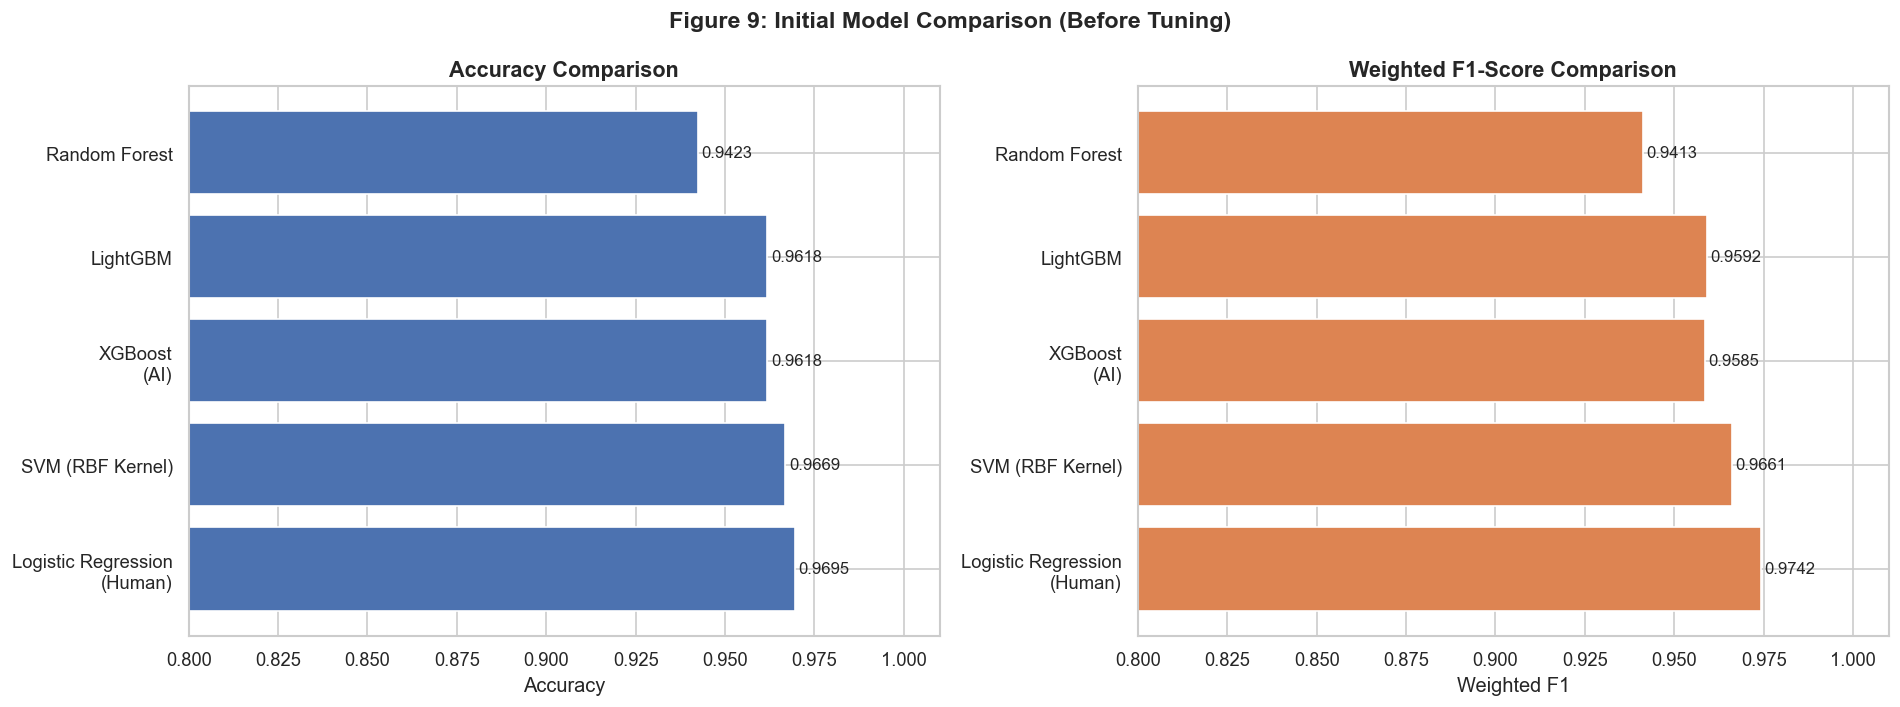

In [10]:
# ─── Bar chart comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = comparison_df['Model'].str.replace(' (Human)', '\n(Human)', regex=False)
model_names = model_names.str.replace(' (AI-Recommended)', '\n(AI)', regex=False)

# Accuracy
axes[0].barh(model_names, comparison_df['Accuracy'], color='#4C72B0', edgecolor='white')
axes[0].set_xlim(0.8, 1.01)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Accuracy')
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

# Weighted F1
axes[1].barh(model_names, comparison_df['Weighted F1'], color='#DD8452', edgecolor='white')
axes[1].set_xlim(0.8, 1.01)
axes[1].set_title('Weighted F1-Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weighted F1')
for i, v in enumerate(comparison_df['Weighted F1']):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Figure 9: Initial Model Comparison (Before Tuning)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_model_comparison.png', bbox_inches='tight')
plt.show()

## 7️⃣ Confusion Matrices

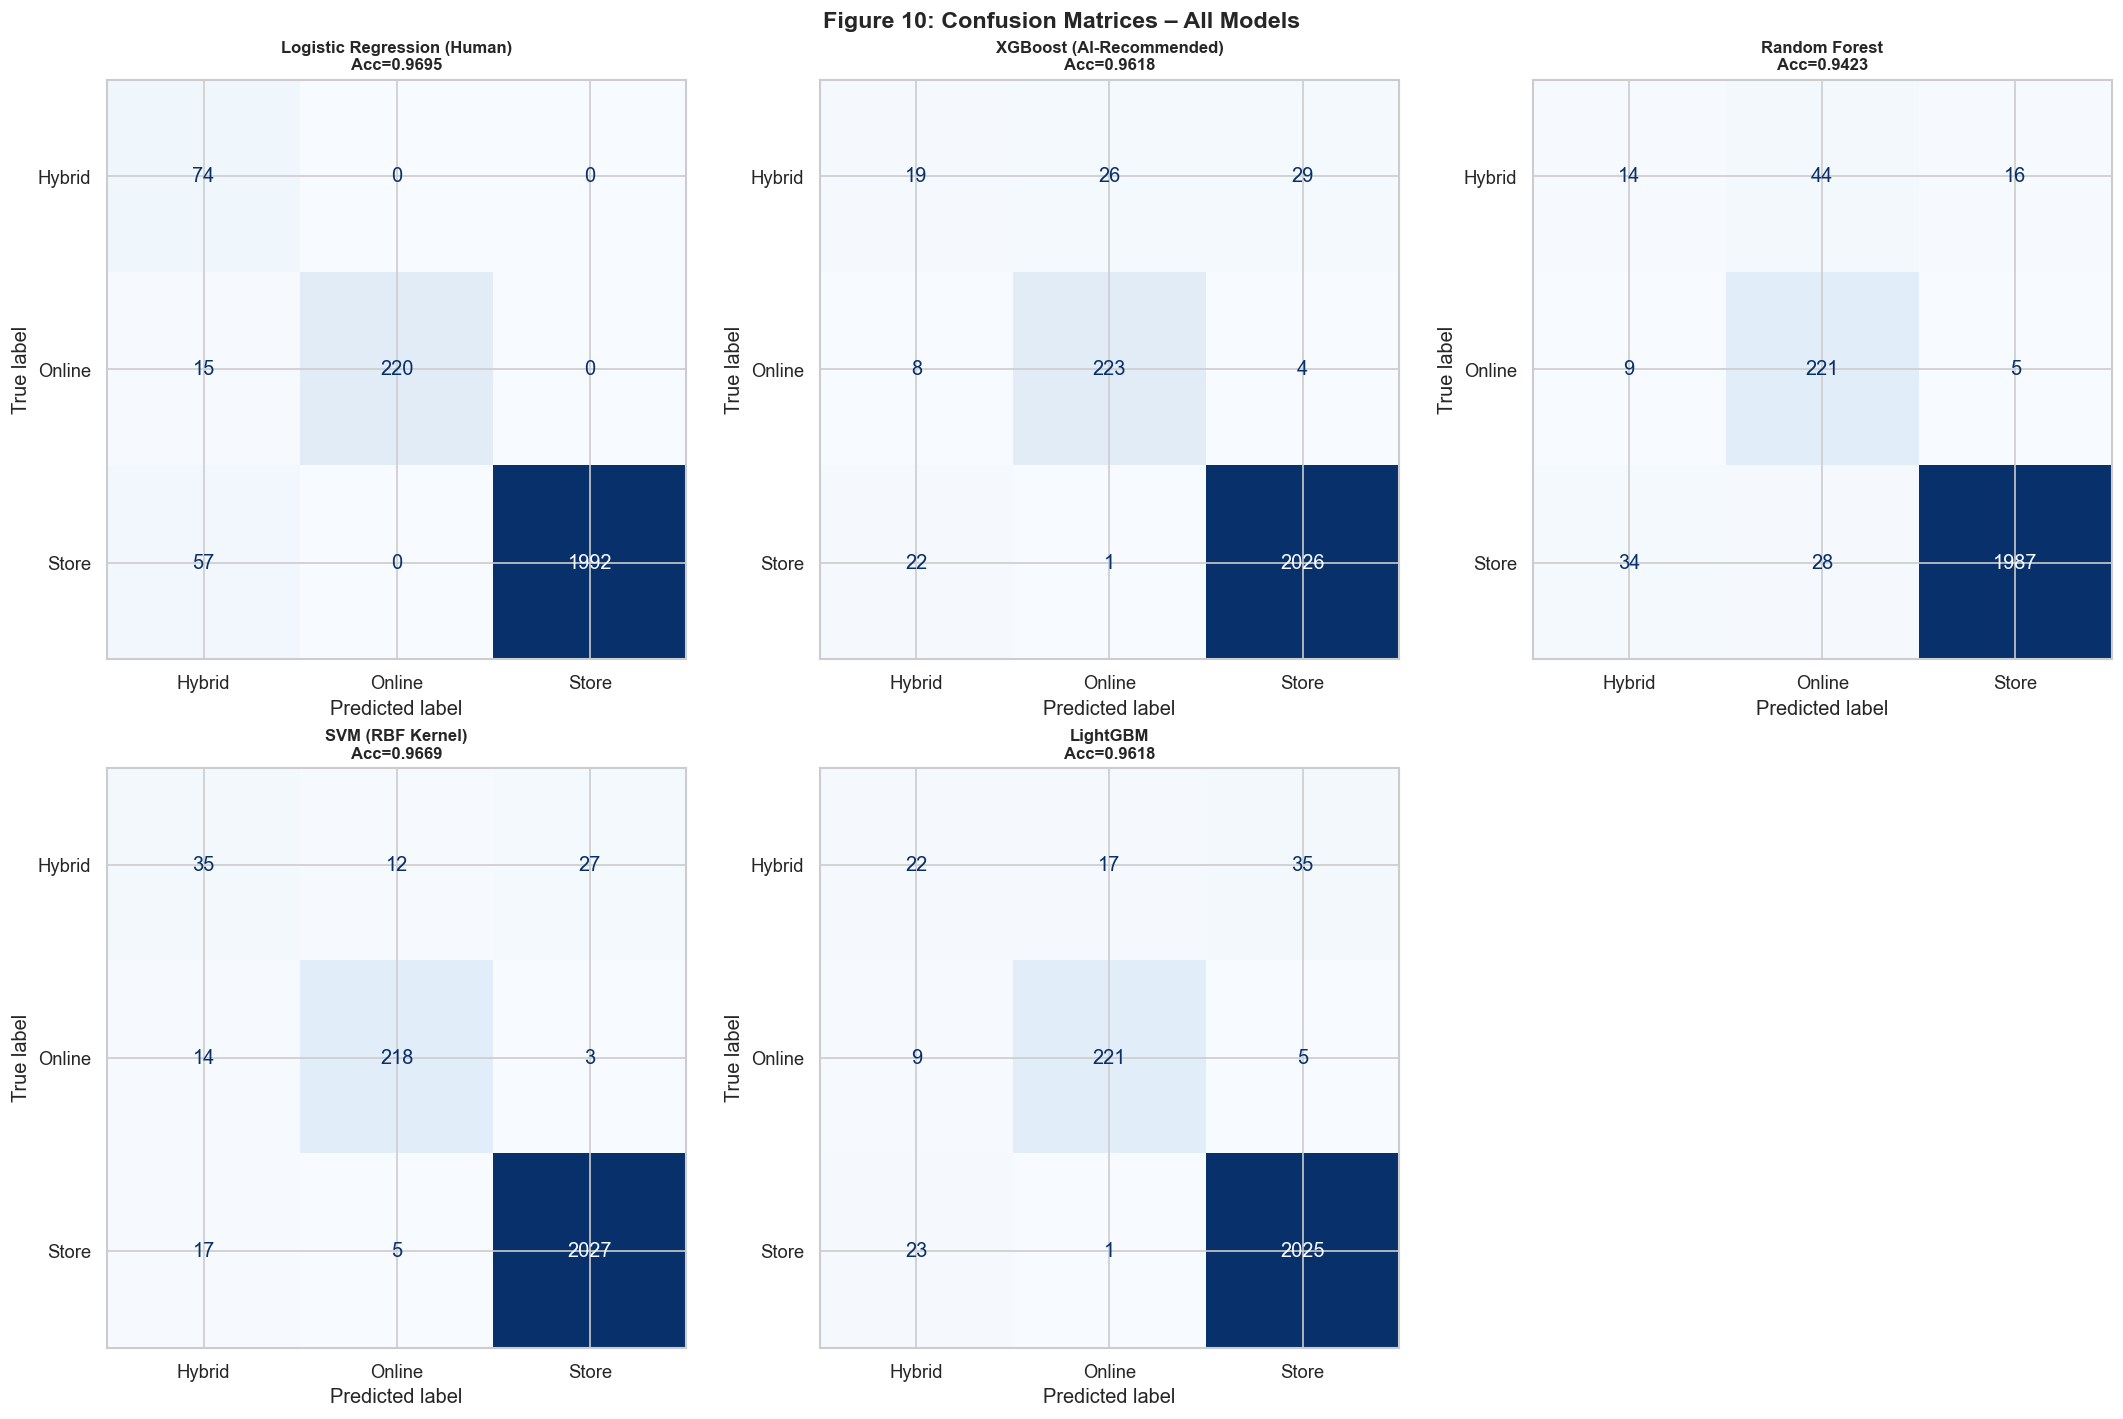

In [11]:
# ─── Confusion matrices for all models ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

top_results = [lr_results, xgb_results, rf_results, svm_results, lgbm_results]

for i, res in enumerate(top_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"{res['Model']}\nAcc={res['Accuracy']:.4f}",
                      fontsize=10, fontweight='bold')

axes[-1].set_visible(False)  # Hide empty subplot

plt.suptitle('Figure 10: Confusion Matrices – All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 8️⃣ Save Models and Results

In [12]:
# ─── Save initial (pre-tuning) models ────────────────────────────────────────
joblib.dump(lr_results['trained_model'],   '../models/logistic_regression_initial.pkl')
joblib.dump(xgb_results['trained_model'],  '../models/xgboost_initial.pkl')
joblib.dump(rf_results['trained_model'],   '../models/random_forest_initial.pkl')
joblib.dump(svm_results['trained_model'],  '../models/svm_initial.pkl')
joblib.dump(lgbm_results['trained_model'], '../models/lightgbm_initial.pkl')

# ─── Save comparison table ────────────────────────────────────────────────────
comparison_df.to_csv('../models/initial_model_comparison.csv', index=False)

print('✅ All models and results saved!')
print('\n📌 Best model so far:', comparison_df.iloc[0]['Model'])
print('   Accuracy:', comparison_df.iloc[0]['Accuracy'])
print('\n➡️  Next: Run hyperparameter_tuning.ipynb')

✅ All models and results saved!

📌 Best model so far: Logistic Regression (Human)
   Accuracy: 0.9695

➡️  Next: Run hyperparameter_tuning.ipynb
